---

# GROUPED AND STACKED BAR CHARTS

---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
a = pd.read_csv('Data/retail_2016_2017.csv', parse_dates=['date'])
a

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.000,0
1,1945945,2016-01-01,1,BABY CARE,0.000,0
2,1945946,2016-01-01,1,BEAUTY,0.000,0
3,1945947,2016-01-01,1,BEVERAGES,0.000,0
4,1945948,2016-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
1054939,3000883,2017-08-15,9,POULTRY,438.133,0
1054940,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
1054941,3000885,2017-08-15,9,PRODUCE,2419.729,148
1054942,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [3]:
retail = pd.read_csv('Data/retail_2016_2017.csv', parse_dates=['date'])

retail = (retail
    .query("family in ['DAIRY', 'POULTRY', 'SEAFOOD', 'MEATS', 'EGGS', 'FROZEN FOODS'] and date.dt.year == 2016 and date.dt.month == 3")
    .pivot_table(index='store_nbr', columns='family', values='sales', aggfunc='sum')
    .astype('int')
)

retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54 entries, 1 to 54
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   DAIRY         54 non-null     int64
 1   EGGS          54 non-null     int64
 2   FROZEN FOODS  54 non-null     int64
 3   MEATS         54 non-null     int64
 4   POULTRY       54 non-null     int64
 5   SEAFOOD       54 non-null     int64
dtypes: int64(6)
memory usage: 3.0 KB


In [4]:
retail.head(3)

family,DAIRY,EGGS,FROZEN FOODS,MEATS,POULTRY,SEAFOOD
store_nbr,,,,,,
1,22763,4426,3422,8316,8551,820
2,31558,5833,4101,10938,15884,1082
3,77095,16045,11186,24410,36374,3238


<br><br>

>---
>
>Plotting multiple series with a bar plot will create a **Groouped Bar Chart**

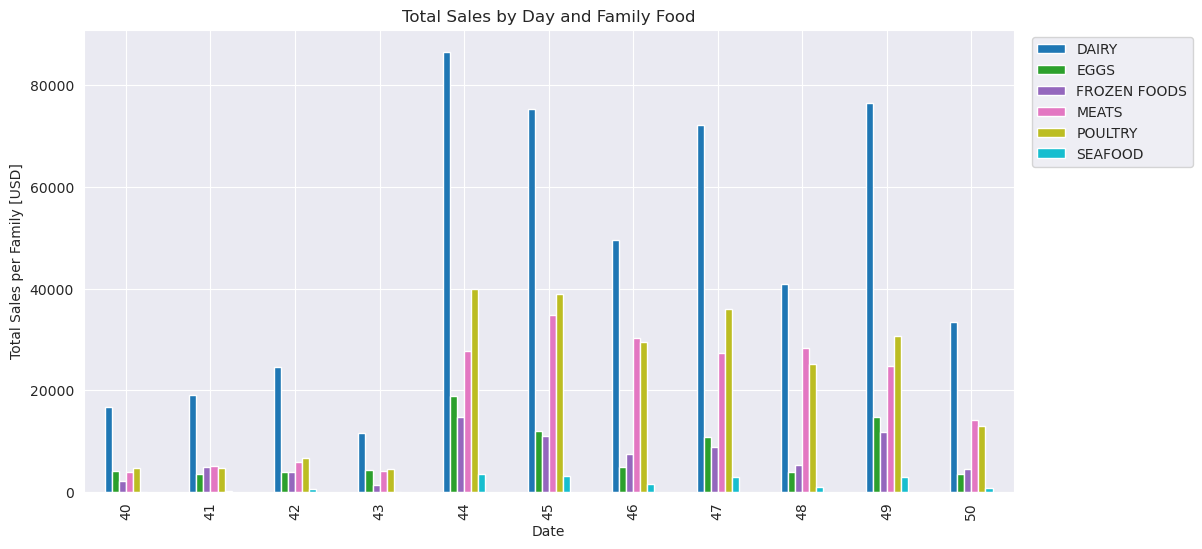

In [5]:
sns.set_style('darkgrid')

retail.iloc[39:50].plot.bar(
    figsize=(12,6),
    cmap='tab10',
    rot=90,
    title='Total Sales by Day and Family Food',
    xlabel='Date',
    ylabel='Total Sales per Family [USD]',
).legend(bbox_to_anchor=(1.2,1));

>---
>
>Specify `stacked=True` when plotting multiple series to create a **Stacked Bar Chart**
>
>- This still let's you compare the categories, but also shows the composition of each category
>
>---

<Axes: title={'center': 'Total Sales by Day and Family Food'}, xlabel='Date', ylabel='Total Sales per Family [USD]'>

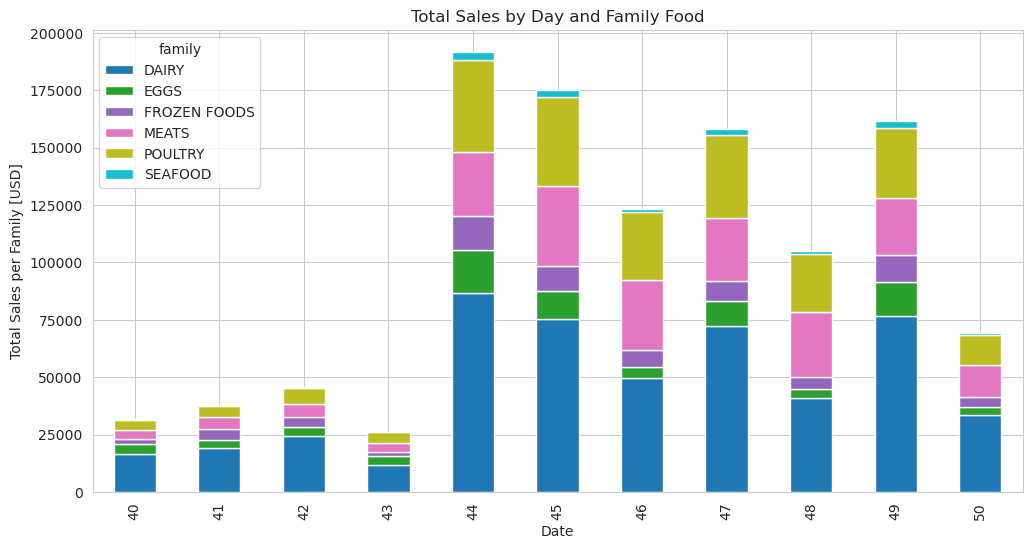

In [6]:
sns.set_style('whitegrid')

retail.iloc[39:50].plot.bar(
    figsize=(12, 6),
    stacked=True,
    cmap='tab10',
    title='Total Sales by Day and Family Food',
    xlabel='Date',
    ylabel='Total Sales per Family [USD]',)

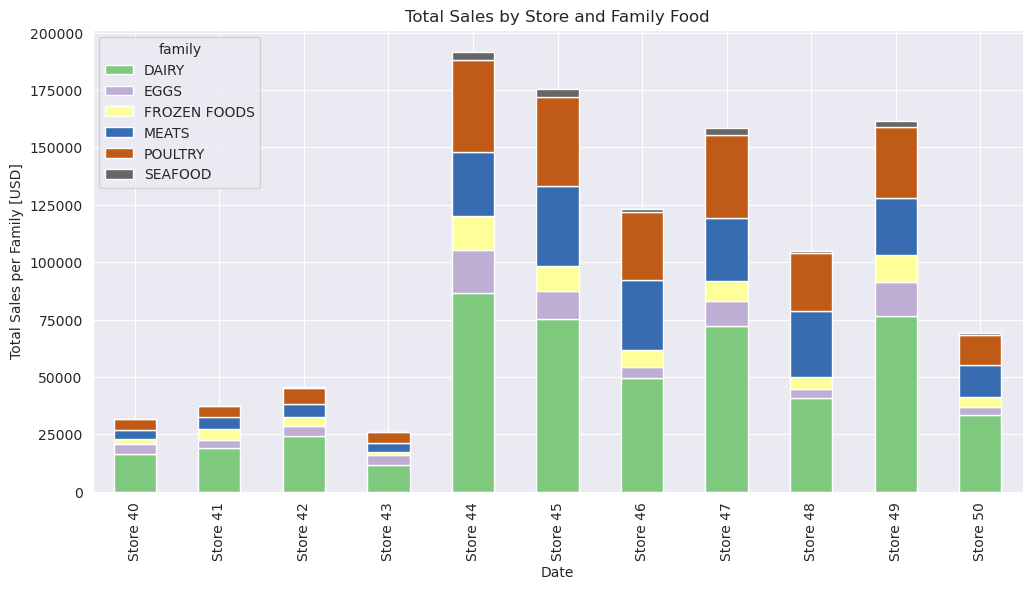

In [7]:
sns.set_style('darkgrid')

(retail.iloc[39:50]
    .plot.bar(figsize=(12, 6),
              stacked=True,
              cmap='Accent',
              title='Total Sales by Store and Family Food',
              xlabel='Date',
              ylabel='Total Sales per Family [USD]',)
                    .set_xticklabels(labels=[f'Store {n+1}' for n in range(39, 50)])
);

<br><br>

>---
>Calculate percent of total values by index to create a **100% Stacked Bar Chart**
>
>- This emphasizes the difference in composition between categories(*instead of absolute values*)
>
>---

In [8]:
# Create the percentage table...
percent_retail = retail.apply(lambda x: (x/sum(x))*100, axis=1).round(2)
percent_retail.head()

family,DAIRY,EGGS,FROZEN FOODS,MEATS,POULTRY,SEAFOOD
store_nbr,,,,,,
1,47.13,9.16,7.09,17.22,17.70,1.70
2,45.48,8.41,5.91,15.76,22.89,1.56
3,45.80,9.53,6.64,14.50,21.61,1.92
4,45.18,8.51,5.19,17.16,22.43,1.52
5,43.02,7.88,8.97,20.45,18.55,1.12


AttributeError: 'Legend' object has no attribute 'set_xticklabels'

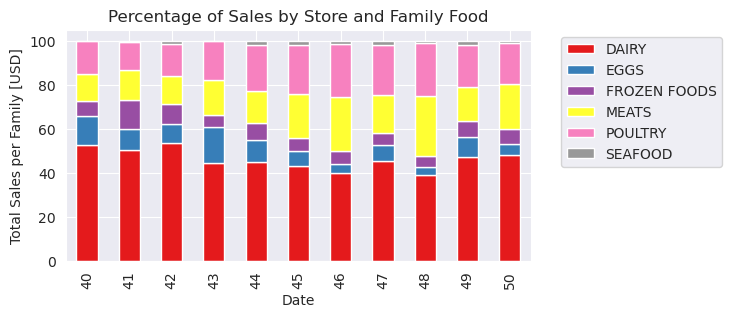

In [9]:
sns.set_style('darkgrid')

(percent_retail.iloc[39:50]
    .plot.bar(figsize=(6, 3),
              stacked=True,
              cmap='Set1',
              title='Percentage of Sales by Store and Family Food',
              xlabel='Date',
              ylabel='Total Sales per Family [USD]',)).legend(bbox_to_anchor=(1.05, 1)).set_xticklabels(labels=[f'Store {n+1}' for n in range(39, 50)]);

<br><br>


## ¿Qué está pasando?

Tu cadena de métodos tiene un problema de orden:

---

```python
# This code produced the AttributeError message
.plot.bar(..., ylabel='...').legend(bbox_to_anchor=(1.2, 1)).set_xticklabels(...)   # ← esto se aplica sobre Legend, no sobre Axes
```

---

>`.legend()` retorna un objeto **Legend**, y **Legend** no tiene `.set_xticklabels()`. Ese método pertenece al objeto **Axes**.

<br><br>

## ¿Por qué esto no es "Matplotlib OOP completo"?

Estás usando `ax` solo como variable de captura para poder llamar dos métodos por separado — no estás creando `fig, ax = plt.subplots()` ni construyendo la figura desde cero. Es el paso mínimo necesario cuando necesitas encadenar más de un método post-plot.

Cuando `.plot.bar()` retorna un objeto **Axes**, guardarlo en `ax` es perfectamente válido dentro del estilo de EDA rápido.


<br><br>


## Solución sin Matplotlib OOP — separar en dos líneas

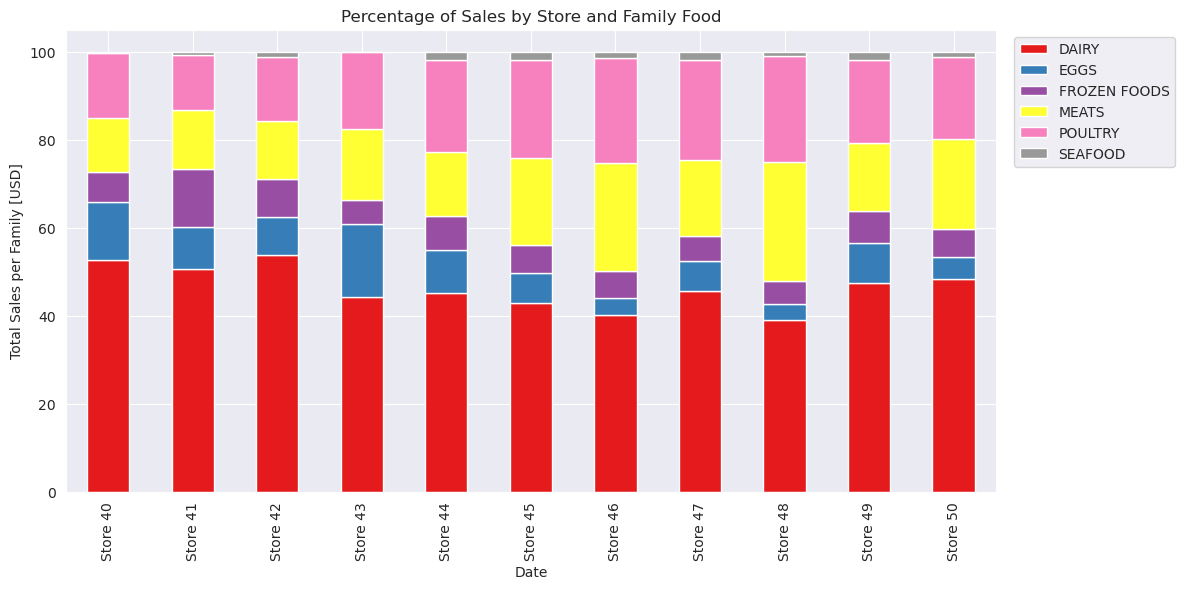

In [10]:
sns.set_style('darkgrid')

ax = (percent_retail.iloc[39:50]
    .plot.bar(figsize=(12, 6),
              stacked=True,
              cmap='Set1',
              title='Percentage of Sales by Store and Family Food',
              xlabel='Date',
              ylabel='Total Sales per Family [USD]',))

ax.legend(bbox_to_anchor=(1.2, 1))
ax.set_xticklabels(labels=[f'Store {n+1}' for n in range(39, 50)]);

---

## LABORATORY

In [11]:
transactions = pd.read_csv('Data/transactions.csv', parse_dates=['date'])

store_40s = list(range(40, 50))

to_plot = (transactions
    .query("store_nbr in @store_40s and date.dt.month in [1, 2, 3]")
    .pivot_table(index=transactions.date.dt.month, columns='store_nbr', values='transactions', aggfunc='sum')
)
to_plot

store_nbr,40,41,42,43,44,45,46,47,48,49
date,,,,,,,,,,
1,185490,148431,64758,188657,628438,538370,522763,568824,439045,386589
2,179215,143437,62400,186951,584046,511411,493100,539453,422158,362406
3,199810,156254,67713,203827,655630,561184,540294,594248,460341,407071


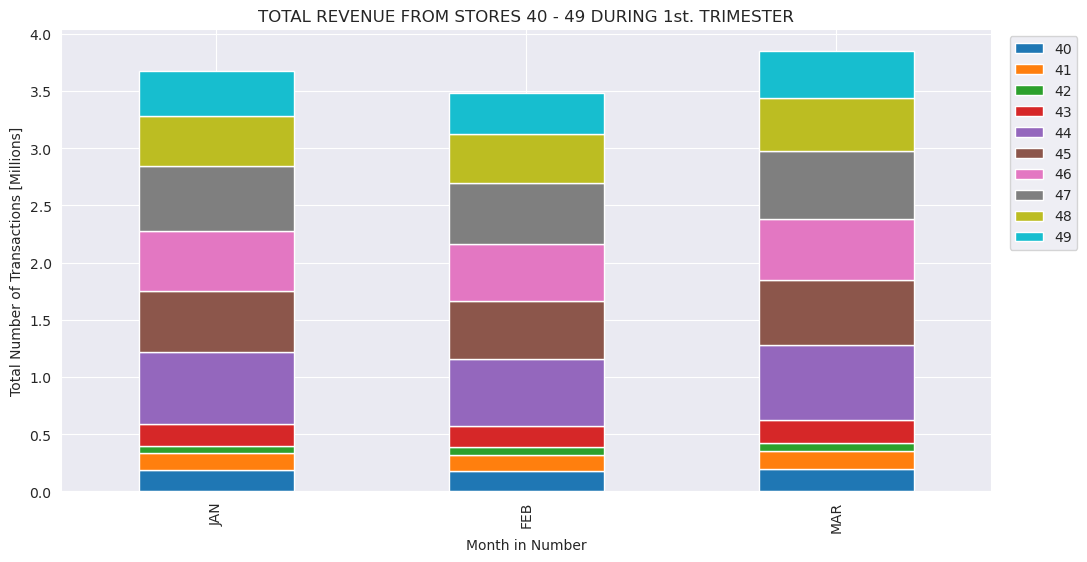

In [12]:
ax = to_plot.apply(lambda x: x/1_000_000).plot.bar(
    figsize=(12,6),
    stacked=True,
    cmap='tab10',
    title='TOTAL REVENUE FROM STORES 40 - 49 DURING 1st. TRIMESTER',
    xlabel='Month in Number',
    ylabel='Total Number of Transactions [Millions]')

ax.legend(bbox_to_anchor=(1.1, 1))
ax.set_xticklabels(labels=['JAN', 'FEB', 'MAR']);

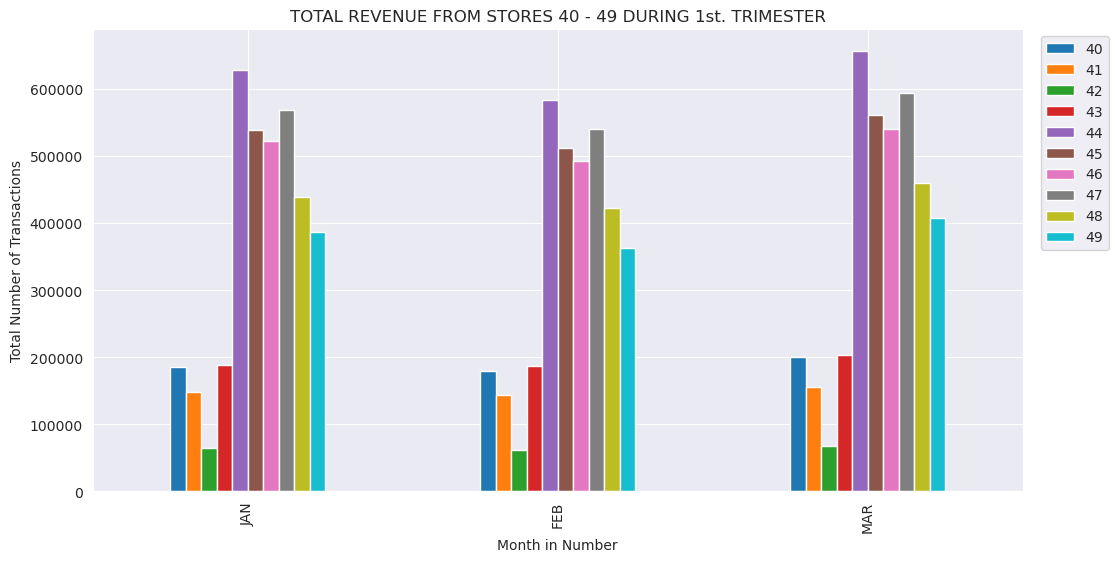

In [13]:
ax = to_plot.plot.bar(
    figsize=(12,6),
    stacked=False,
    cmap='tab10',
    title='TOTAL REVENUE FROM STORES 40 - 49 DURING 1st. TRIMESTER',
    xlabel='Month in Number',
    ylabel='Total Number of Transactions')

ax.legend(bbox_to_anchor=(1.1, 1))
ax.set_xticklabels(labels=['JAN', 'FEB', 'MAR']);

---

In [14]:
# Calculte percentage
to_plot2 = (transactions
    .query("store_nbr in @store_40s and date.dt.month in [1, 2, 3]")
    .pivot_table(index=transactions.date.dt.month, columns='store_nbr', values='transactions', aggfunc='sum').apply(lambda x: (x/sum(x)*100), axis=1)
)
to_plot2

store_nbr,40,41,42,43,44,45,46,47,48,49
date,,,,,,,,,,
1,5.052344,4.042938,1.763867,5.138606,17.117285,14.664028,14.238927,15.493529,11.958631,10.529844
2,5.143092,4.116339,1.790748,5.365099,16.760887,14.676416,14.150929,15.481162,12.115043,10.400287
3,5.194765,4.062374,1.760438,5.299201,17.045413,14.589956,14.046847,15.449572,11.968187,10.583246


[Text(0, 0, 'JANUARY'), Text(1, 0, 'FEBRUARY'), Text(2, 0, 'MARCH')]

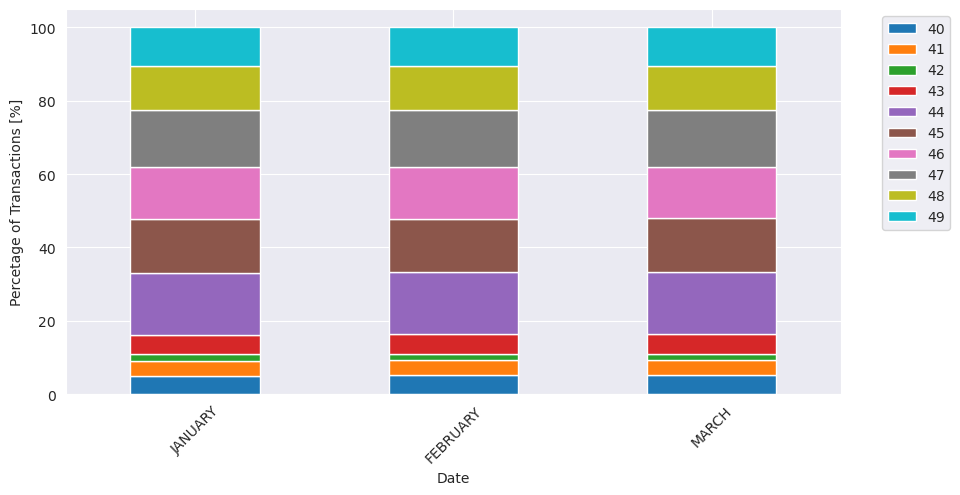

In [15]:
ax = to_plot2.plot.bar(
    figsize=(10, 5),
    stacked=True,
    cmap='tab10',
    rot=45,
    xlabel="Date",
    ylabel='Percetage of Transactions [%]')
    
ax.legend(bbox_to_anchor=(1.15, 1))
ax.set_xticklabels(labels=['JANUARY', 'FEBRUARY', 'MARCH'])

---

# Lesson Notes

¿Qué tipo de objeto es ax?:            <class 'matplotlib.axes._axes.Axes'>

¿Qué retorna .legend()?:               <class 'matplotlib.legend.Legend'>

¿Qué retorna .set_xticklabels()?:      <class 'list'>




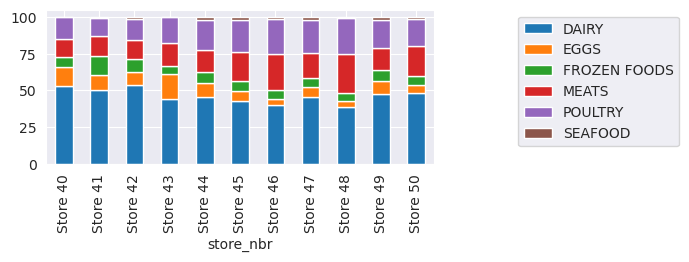

In [16]:
ax = percent_retail.iloc[39:50].plot.bar(figsize=(5, 2), stacked=True)

# ¿Qué tipo de objeto es ax?
print(f'¿Qué tipo de objeto es ax?:            {type(ax)}\n')

# ¿Qué retorna .legend()?
legend_obj = ax.legend(bbox_to_anchor=(1.2, 1))
print(f'¿Qué retorna .legend()?:               {type(legend_obj)}\n')

# ¿Qué retorna .set_xticklabels()?
tick_obj = ax.set_xticklabels([f'Store {n+1}' for n in range(39, 50)])
print(f'¿Qué retorna .set_xticklabels()?:      {type(tick_obj)}\n\n')

In [17]:
help(ax.set_xticklabels)   # documentación completa del método

Help on method set_xticklabels in module matplotlib.axes._base:

set_xticklabels(labels, *, minor=False, fontdict=None, **kwargs) method of matplotlib.axes._axes.Axes instance
    [*Discouraged*] Set the xaxis' tick labels with list of string labels.

    .. admonition:: Discouraged

        The use of this method is discouraged, because of the dependency on
        tick positions. In most cases, you'll want to use
        ``Axes.set_[x/y/z]ticks(positions, labels)`` or ``Axes.set_xticks``
        instead.

        If you are using this method, you should always fix the tick
        positions before, e.g. by using `.Axes.set_xticks` or by explicitly
        setting a `~.ticker.FixedLocator`. Otherwise, ticks are free to
        move and the labels may end up in unexpected positions.

    Parameters
    ----------
    labels : sequence of str or of `.Text`\s
        Texts for labeling each tick location in the sequence set by
        `.Axes.set_xticks`; the number of labels must match t

In [18]:
help(ax.legend)   # documentación completa del método

Help on method legend in module matplotlib.axes._axes:

legend(*args, **kwargs) method of matplotlib.axes._axes.Axes instance
    Place a legend on the Axes.

    Call signatures::

        legend()
        legend(handles, labels)
        legend(handles=handles)
        legend(labels)

    The call signatures correspond to the following different ways to use
    this method:

    **1. Automatic detection of elements to be shown in the legend**

    The elements to be added to the legend are automatically determined,
    when you do not pass in any extra arguments.

    In this case, the labels are taken from the artist. You can specify
    them either at artist creation or by calling the
    :meth:`~.Artist.set_label` method on the artist::

        ax.plot([1, 2, 3], label='Inline label')
        ax.legend()

    or::

        line, = ax.plot([1, 2, 3])
        line.set_label('Label via method')
        ax.legend()

    .. note::
        Specific artists can be excluded from the autom

In [19]:
# Ver qué métodos y atributos tiene el objeto Axes
# Todos los métodos disponibles en Axes
print(dir(ax))

['ArtistList', '_AxesBase__clear', '_PROPERTIES_EXCLUDED_FROM_SET', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_add_text', '_adjustable', '_agg_filter', '_alias_map', '_alpha', '_anchor', '_animated', '_aspect', '_autotitlepos', '_axes', '_axes_locator', '_axis_map', '_axis_names', '_axisbelow', '_box_aspect', '_callbacks', '_check_no_units', '_children', '_clipon', '_clippath', '_cm_set', '_colorbars', '_convert_dx', '_current_image', '_different_canvas', '_errorevery_to_mask', '_facecolor', '_fill_between_process_units', '_fill_between_x_or_y', '_forward_navigation_events', '_frameon', '_fully_clipped_to_axes', '_gci', '_gen_axes_patch',

In [20]:
# Filtrar solo los que contienen "tick"
print([m for m in dir(ax) if 'tick' in m])

['_sticky_edges', '_use_sticky_edges', 'get_xmajorticklabels', 'get_xminorticklabels', 'get_xticklabels', 'get_xticklines', 'get_xticks', 'get_ymajorticklabels', 'get_yminorticklabels', 'get_yticklabels', 'get_yticklines', 'get_yticks', 'minorticks_off', 'minorticks_on', 'set_xticklabels', 'set_xticks', 'set_yticklabels', 'set_yticks', 'sticky_edges', 'tick_params', 'ticklabel_format', 'use_sticky_edges']
